# Task 1 — Equity research pipeline

Prices → indicators (no TA-Lib) → news → LLM signal → HTML brief.

**Env:** local uses `.env`. Colab uses Secrets (key icon). `src/config.py` selects the source.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# After you create the GitHub repo, put the HTTPS clone URL here.
REPO_URL = os.environ.get(
    "FINANCIAL_AI_REPO",
    "https://github.com/lavanblavan/Financial_AI.git",
)

def ensure_project() -> Path:
    if IN_COLAB:
        root = Path("/content/Financial_AI")
        if not (root / "src/config.py").exists():
            subprocess.run(["git", "clone", REPO_URL, str(root)], check=True)
        else:
            subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
        os.chdir(root)
    else:
        root = Path.cwd().resolve()
        if not (root / "src/config.py").exists():
            raise FileNotFoundError("Run this notebook from the repo root so src/ is visible.")

    req = root / "requirements.txt"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=True)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    return root

ROOT = ensure_project()
print("project root:", ROOT)
print("runtime:", "colab" if IN_COLAB else "local")

project root: /content/Financial_AI
runtime: colab


In [2]:
from src.config import describe_env, load_settings, missing_key_help

settings = load_settings()
print(describe_env(settings))
if not settings.llm_ready:
    print(missing_key_help(settings))

{'runtime': 'colab', 'secret_source': 'colab-secrets', 'ticker': 'AAPL', 'lookback': '2y', 'llm_provider': 'groq', 'llm_key_present': 'yes', 'groq_key_shape': 'gsk_*', 'groq_secret_status': 'present'}


In [3]:
from src.data import fetch_prices

prices = fetch_prices(settings.ticker, period=settings.lookback)
prices.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-02,326.869995,328.399994,323.529999,324.959991,33776400
2026-09-03,324.869995,330.809998,324.109985,328.209991,37225800
2026-09-04,328.309998,328.929993,317.859985,319.970001,39606900
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65371600


In [4]:
from src.indicators import add_indicators, latest_snapshot

df = add_indicators(prices)
snapshot = latest_snapshot(df)
display(df[["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_hist"]].tail())
snapshot

,Close,sma_50,sma_200,rsi_14,macd,macd_hist
Date,,,,,,
2026-09-02,324.959991,313.378975,282.890147,60.954474,1.951511,1.751697
2026-09-03,328.209991,314.086626,283.172845,63.479375,2.724499,2.019748
2026-09-04,319.970001,314.987768,283.439025,53.953206,2.641747,1.549596
2026-09-08,316.220001,315.641459,283.686555,50.256878,2.247662,0.924409
2026-09-09,315.339996,316.318314,283.924100,49.401551,1.843091,0.415871


{'date': '2026-09-09',
 'close': 315.3399963378906,
 'sma_50': 316.31831420898436,
 'sma_200': 283.9241000366211,
 'sma_cross': 'bullish',
 'sma_cross_flipped': False,
 'rsi_14': 49.401551032112216,
 'macd': 1.8430912849237302,
 'macd_signal': 1.4272202662070108,
 'macd_hist': 0.4158710187167194,
 'bb_upper': 327.9350811844555,
 'bb_mid': 314.0594985961914,
 'bb_lower': 300.18391600792734,
 'bb_position': 'mid_band',
 'momentum_bias': 'bullish'}

## Indicator charts

Seaborn draws one static panel per indicator. Plotly below is interactive: hover, zoom, pan, and a range slider. Seaborn cannot do that by itself.

In [ ]:
from src.plots import plot_all_seaborn, plot_interactive

for fig in plot_all_seaborn(df, ticker=settings.ticker):
    display(fig)

In [ ]:
interactive = plot_interactive(df, ticker=settings.ticker)
interactive.show()

In [5]:
from src.news import fetch_news

headlines = fetch_news(settings.ticker, min_items=10)
print(f"{len(headlines)} headlines")
headlines

10 headlines


[{'title': 'How John Ternus understood the assignment in the Apple launch event opener',
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-09T21:30',
  'source': 'yfinance'},
 {'title': "Foldable iPhone Duo's software helps it 'shine' against competitors",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-09T19:31',
  'source': 'yfinance'},
 {'title': 'Apple reveals the foldable iPhone Duo',
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-09T18:36',
  'source': 'yfinance'},
 {'title': "Here's the competition Apple’s foldable iPhone faces",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-09T15:00',
  'source': 'yfinance'},
 {'title': "John Ternus's biggest challenges as Apple's new CEO",
  'publisher': 'Yahoo Finance',
  'date': '2026-09-01T10:00',
  'source': 'yfinance'},
 {'title': 'Dow Jones Futures Rise After Oil Prices, Yields Hit Stocks; Inflation Data Due.',
  'publisher': "Investor's Business Daily",
  'date': '2026-09-10T03:09',
  'source': 'yfin

In [6]:
from src.signal import GroqAPIError, LLMNotConfiguredError, build_signal

try:
    result = build_signal(snapshot, headlines, settings, settings.ticker)
except (LLMNotConfiguredError, GroqAPIError) as exc:
    result = {
        "signal": "HOLD",
        "confidence": 0.0,
        "horizon": "n/a",
        "rationale": str(exc),
        "bull_case": "",
        "bear_case": "",
        "risks": ["LLM key not configured"],
    }
result

{'signal': 'BUY',
 'confidence': 0.7,
 'horizon': '1-4 weeks',
 'rationale': 'SMA‑50 is just below the price but the bullish SMA cross and MACD histogram turning positive indicate an upward momentum that is not yet reflected in the close. RSI sits near 49, avoiding overbought territory, while momentum bias is bullish and the price is in the middle Bollinger band, suggesting room to climb. Recent headlines focus on the launch of the foldable iPhone Duo, with positive commentary on its design and potential to capture a premium segment, reinforcing the technical upside. Combined, the indicators and news point to a moderate‑to‑strong bullish case for the near term.',
 'bull_case': 'Apple’s new foldable iPhone Duo, positioned at a premium price, could revive the company’s device‑design leadership and open a new high‑margin product line. Strong brand loyalty, a robust ecosystem, and early positive reviews suggest the product may attract early adopters and generate significant incremental rev

wrote /content/Financial_AI/outputs/AAPL_brief.html



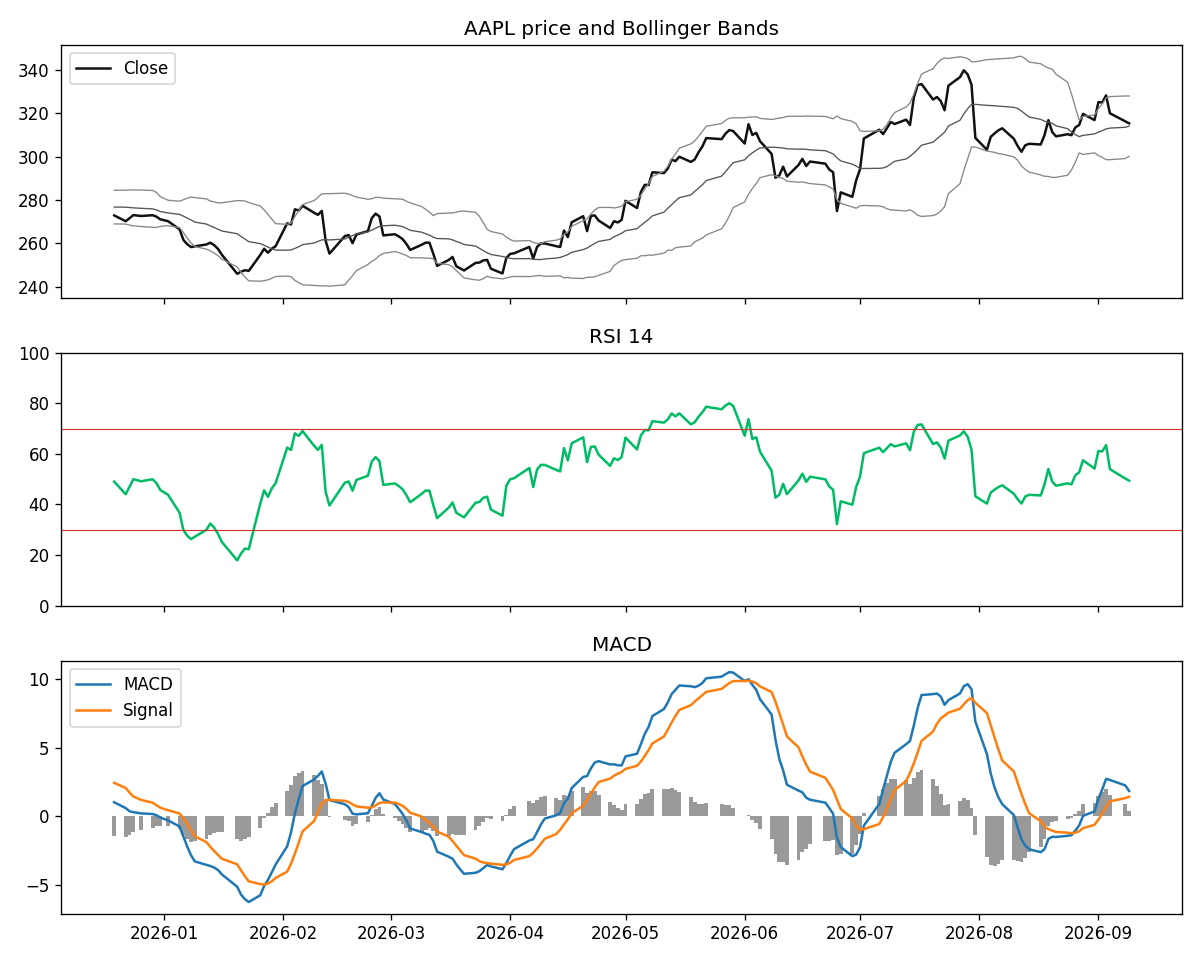

In [7]:
from IPython.display import HTML, display
from src.report import render_brief

brief_path = render_brief(settings.ticker, df, snapshot, headlines, result)
print("wrote", brief_path)
display(HTML(brief_path.read_text(encoding="utf-8")))